# Flow Locking Analysis — L(n), antisymmetry A(n), and the locking visual

**Paper 1, §4 (Figs 6 & 7).** Quantifies how strongly the mean flow repeats with the
geometry's twist-and-repeat rule.

**Key fact about the data:** the `*_transformed` CSVs are already de-rotated into a
common frame (each layer rotated by its `alpha` about the column axis). So a *locked*
flow means the transformed layer fields should **coincide**. We therefore:
1. load layers L13–L17 (a given position) on the common (X, Z) plane,
2. interpolate each onto a shared grid,
3. show them side-by-side + their mean (Fig 6 — they overlap if locked),
4. compute the locking order parameter L (cosine similarity between layers) → Fig 7,
5. compute the antisymmetry index A about the column axis.

Columns used: `Points_0`=X (transverse, across width), `Points_2`=Z (streamwise,
within the 10 mm layer); `av_u_0`=transverse velocity, `av_u_2`=streamwise velocity,
`av_u_Magnitude`=speed.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os, re, glob

# ----------------- CONFIG (edit these) -----------------
BASE = '../30/sim/30_Re_100/'   # topology/Re folder   '../40/sim/40_degree_jet_00' 
POS  = 'Pos1_transformed'           # Pos1/Pos3/Pos5/Pos7_transformed
TOPO_LABEL = '30 deg, Re=100, Pos1' #'30 deg, Re=100, Pos3' # for titles
OUTDIR = 'locking'  # where to save output figures
GRID_N = 240                        # grid points across the wide (X) direction
os.makedirs(OUTDIR, exist_ok=True)

folder = os.path.join(BASE, POS)
files = sorted(glob.glob(os.path.join(folder, 'SIM_L*_T_transformed.csv')))
files = files[::-1]  # Reverse to match layer order
print('Found', len(files), 'layer files:')
for f in files: print('  ', os.path.basename(f))

Found 5 layer files:
   SIM_L17_Pos1_Re100_B0001_T_transformed.csv
   SIM_L16_Pos1_Re100_B0001_T_transformed.csv
   SIM_L15_Pos1_Re100_B0001_T_transformed.csv
   SIM_L14_Pos1_Re100_B0001_T_transformed.csv
   SIM_L13_Pos1_Re100_B0001_T_transformed.csv


In [59]:
# ----------------- load layers -----------------
def layer_number(path):
    m = re.search(r'_L(\d+)_', os.path.basename(path))
    return int(m.group(1)) if m else -1

def load_layer(path):
    df = pd.read_csv(path)
    z = df['Points_2'].values
    return dict(
        X=df['Points_0'].values,            # transverse (across width)
        # each layer is a distinct 10 mm streamwise slab -> use layer-local Z
        # (subtract the slab's own minimum) so all layers overlay on one grid:
        Z=z - z.min(),                      # streamwise, layer-local [0, ~10 mm]
        U=df['av_u_0'].values,              # transverse velocity
        W=df['av_u_2'].values,              # streamwise velocity
        M=df['av_u_Magnitude'].values,
    )

layers = {layer_number(f): load_layer(f) for f in files}
lnums = sorted(layers)
print('Layers:', lnums)

# common plane extent (symmetric in X so we can test antisymmetry about X=0)
Xmax = min(abs(min(d['X'].min() for d in layers.values())),
           abs(max(d['X'].max() for d in layers.values())))
Zmin = max(d['Z'].min() for d in layers.values())   # ~0 with layer-local Z
Zmax = min(d['Z'].max() for d in layers.values())   # ~10 mm
nz = max(8, int(GRID_N * (Zmax - Zmin) / (2*Xmax)))
xi = np.linspace(-Xmax, Xmax, GRID_N)
zi = np.linspace(Zmin, Zmax, nz)
XI, ZI = np.meshgrid(xi, zi)
print(f'grid: {GRID_N} x {nz}   X=+/-{Xmax*1e3:.1f} mm   Z=[{Zmin*1e3:.1f},{Zmax*1e3:.1f}] mm')

Layers: [13, 14, 15, 16, 17]
grid: 240 x 57   X=+/-20.8 mm   Z=[0.0,10.0] mm


In [60]:
# ----------------- interpolate each layer onto the shared grid -----------------
def grid_field(d, key):
    return griddata((d['X'], d['Z']), d[key], (XI, ZI), method='linear')

G = {}        # G[n] = gridded U, W, M
valid = {}    # valid[n] = finite-fluid mask for layer n
for n in lnums:
    G[n] = {k: grid_field(layers[n], k) for k in ('U', 'W', 'M')}
    valid[n] = np.isfinite(G[n]['U']) & np.isfinite(G[n]['W'])

# Do NOT intersect over all layers (that collapses to ~0 with many layers).
# Compare each pair on the points they share.
coverage = np.sum([valid[n] for n in lnums], axis=0)  # #layers covering each pixel
print('per-layer valid pixels:', {n: int(valid[n].sum()) for n in lnums})
print('pixels covered by >=2 layers:', int((coverage >= 2).sum()), '/', coverage.size)

def pair_mask(a, b):
    return valid[a] & valid[b]

per-layer valid pixels: {13: 13434, 14: 13490, 15: 13338, 16: 13490, 17: 13434}
pixels covered by >=2 layers: 13452 / 13680


## Fig 6 — the locking visual
Each transformed layer, plus the across-layer mean. If the flow is locked, the layers
look the same as each other and as the mean (small residual).

Layer-to-layer L matrix:
[[1.    0.997 0.997 0.999 0.994]
 [0.997 1.    0.998 0.996 0.995]
 [0.997 0.998 1.    0.997 0.995]
 [0.999 0.996 0.997 1.    0.996]
 [0.994 0.995 0.995 0.996 1.   ]]

L(n) vs mean: {13: 0.999, 14: 0.999, 15: 0.999, 16: 0.999, 17: 0.997}

Mean off-diagonal L = 0.997  (locking score; ->1 = locked)


C:\Users\Safari\AppData\Local\Temp\ipykernel_18220\3653301070.py:14: RuntimeWarning: Mean of empty slice
  Umean = np.nanmean([np.where(valid[n], G[n]['U'], np.nan) for n in lnums], axis=0)
C:\Users\Safari\AppData\Local\Temp\ipykernel_18220\3653301070.py:15: RuntimeWarning: Mean of empty slice
  Wmean = np.nanmean([np.where(valid[n], G[n]['W'], np.nan) for n in lnums], axis=0)


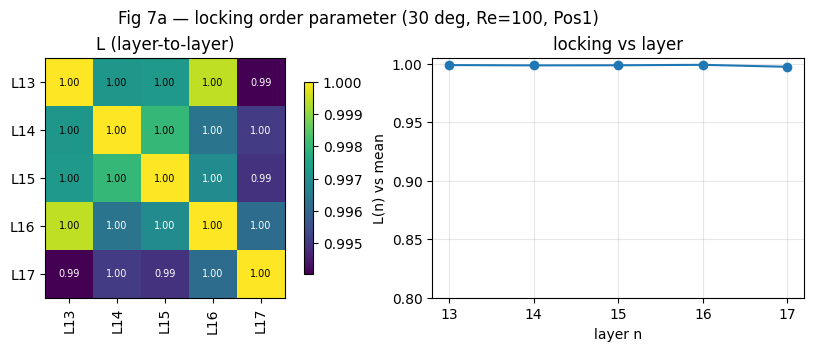

In [61]:
def cos_sim(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

# pairwise L: compare each pair only on the points they share
def Lpair(a, b):
    m = pair_mask(a, b)
    va = np.concatenate([G[a]['U'][m], G[a]['W'][m]])
    vb = np.concatenate([G[b]['U'][m], G[b]['W'][m]])
    return cos_sim(va, vb)

Lmat = np.array([[Lpair(m, n) for n in lnums] for m in lnums])

# L of each layer vs the across-layer mean field
Umean = np.nanmean([np.where(valid[n], G[n]['U'], np.nan) for n in lnums], axis=0)
Wmean = np.nanmean([np.where(valid[n], G[n]['W'], np.nan) for n in lnums], axis=0)
meanvalid = np.isfinite(Umean) & np.isfinite(Wmean)
def Lmean(n):
    m = valid[n] & meanvalid
    return cos_sim(np.concatenate([G[n]['U'][m], G[n]['W'][m]]),
                   np.concatenate([Umean[m], Wmean[m]]))
L_vs_mean = np.array([Lmean(n) for n in lnums])

print('Layer-to-layer L matrix:')
print(np.array2string(Lmat, precision=3, suppress_small=True))
print('\nL(n) vs mean:', dict(zip(lnums, np.round(L_vs_mean, 3))))
offdiag = Lmat[~np.eye(len(lnums), dtype=bool)]
print(f'\nMean off-diagonal L = {offdiag.mean():.3f}  (locking score; ->1 = locked)')
np.savetxt(os.path.join(OUTDIR, f'locking_data_{TOPO_LABEL.replace(", ", "_").replace(" ", "_")}.dat'), 
           np.column_stack([lnums, L_vs_mean, Lmat.diagonal()]),
           header='layer L_vs_mean L_diagonal', fmt='%d %.6f %.6f')

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
im = ax[0].imshow(Lmat, vmin=offdiag.min(), vmax=1, cmap='viridis')
ax[0].set_xticks(range(len(lnums))); ax[0].set_xticklabels([f'L{n}' for n in lnums], rotation=90)
ax[0].set_yticks(range(len(lnums))); ax[0].set_yticklabels([f'L{n}' for n in lnums])
for (i, j), v in np.ndenumerate(Lmat):
    ax[0].text(j, i, f'{v:.2f}', ha='center', va='center',
               color='w' if v < 0.5*(1+offdiag.min()) else 'k', fontsize=7)
ax[0].set_title('L (layer-to-layer)'); fig.colorbar(im, ax=ax[0], shrink=0.8)
ax[1].plot(lnums, L_vs_mean, 'o-'); ax[1].set_ylim(min(0.8, L_vs_mean.min()-0.02), 1.005)
ax[1].set_xlabel('layer n'); ax[1].set_ylabel('L(n) vs mean'); ax[1].grid(alpha=0.3)
ax[1].set_title('locking vs layer')
fig.suptitle(f'Fig 7a — locking order parameter ({TOPO_LABEL})')
fig.savefig(os.path.join(OUTDIR, f'Ln_{TOPO_LABEL.replace(", ", "_").replace(" ", "_")}.png'), dpi=200)
plt.show()

## Fig 7b — antisymmetry A(n) about the column axis
Across the axis (X = 0) the transverse velocity should reverse sign and the streamwise
velocity should be mirrored: A compares U(X,Z) with -U(-X,Z) (and W with W(-X)).
A -> 1 means the field has the expected antisymmetry of the locked state.

A(n): {13: -0.071, 14: -0.078, 15: -0.069, 16: -0.069, 17: -0.063}


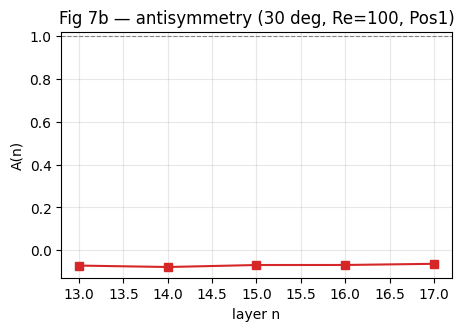

In [62]:
# grid is symmetric in X (xi = -Xmax..Xmax), so flipping columns mirrors X -> -X
def antisym(n):
    U = G[n]['U']; W = G[n]['W']
    Uref = -U[:, ::-1]   # transverse: antisymmetric
    Wref =  W[:, ::-1]   # streamwise: symmetric
    m = valid[n] & valid[n][:, ::-1]   # points whose mirror is also fluid in this layer
    a = np.concatenate([U[m], W[m]])
    b = np.concatenate([Uref[m], Wref[m]])
    return cos_sim(a, b)

A = np.array([antisym(n) for n in lnums])
print('A(n):', dict(zip(lnums, np.round(A, 3))))

fig, ax = plt.subplots(figsize=(4.5, 3.2), constrained_layout=True)
ax.plot(lnums, A, 's-', color='C3'); ax.axhline(1, ls='--', c='gray', lw=0.8)
ax.set_xlabel('layer n'); ax.set_ylabel('A(n)'); ax.set_ylim(min(0.0, A.min()-0.05), 1.02)
ax.grid(alpha=0.3); ax.set_title(f'Fig 7b — antisymmetry ({TOPO_LABEL})')
fig.savefig(os.path.join(OUTDIR, 'fig7b_An.png'), dpi=200)
plt.show()

## Next steps
- **Irregular control:** rerun with `BASE` pointing to the irregular case — expect the
  L matrix and L(n) to drop well below the 30° values (locking absent).
- **40°:** rerun for 40° (period N=9) — expect locking but typically weaker.
- **Re effect:** rerun for 40° at Re=300/500 to show L weakening with Reynolds number.
- **Across positions:** loop POS over Pos1/3/5/7 and average L for a position-robust
  locking score.
- To compare topologies/Re on one plot, collect the `Mean off-diagonal L` (and A) from
  each run into a small table → Fig 10 summary.